# Urban Growth Prediction — Enhanced with Road Proximity and City Position

## What are we predicting, and from what?

**Task:** for each pixel that is **not a building** in year t, predict the probability it becomes a new building in year t+1.

**Evaluated on:** 2022→2023 transition in 5 held-out cities not seen during training.

This is the same task as `open_buildings_temporal_training.ipynb`. The only change is richer input features.

---

## Models compared

| # | Model | Input channels | What it tests |
|---|---|---|---|
| 1 | **Geometric baseline** | — | `1/(1+dist_to_nearest_building)` for each empty pixel. No neural network. Floor — DL models should beat this. |
| 2 | **Original UNet** *(loaded from training notebook)* | presence, prev growth, edge zone, year index | DL baseline. Same model already evaluated in the training notebook. |
| 3 | **+ Road proximity** | all mentioned above + `1/(1+dist_to_road/300m)` | Does knowing how close each pixel is to a road improve predictions? Road data from OpenStreetMap. |
| 4 | **+ Road + City-centre distance** | all mentioned above + normalised distance from AOI centre | Does knowing where in the city the patch sits (core vs fringe) further help? |

Each model adds exactly one thing over the one above it, so the PR-AUC difference between rows isolates the contribution of each new feature.

**All models are saved to disk and seed-controlled.** If kernel variables are lost, re-running cell 9 will reload saved weights instantly — no retraining needed.

*Feature rationale:* Brandily et al. (2024), *Journal of Regional Science* — road density in city centres predicts population growth in Sub-Saharan African cities. The original model has no spatial position signal at all.

In [1]:
import json
import random
import re
import urllib.parse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import rasterio
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from rasterio.enums import Resampling
from rasterio.features import rasterize as rasterio_rasterize
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from scipy.ndimage import binary_dilation, distance_transform_edt
from shapely.geometry import box
from shapely.ops import transform as shapely_transform
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    import osmnx as ox
    ox.settings.log_console = False
except ImportError:
    raise ImportError("Install osmnx: pip install osmnx")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

PROJECT_DIR = Path.cwd()
CACHE_DIR   = PROJECT_DIR / "data" / "cache"     / "open_buildings_temporal"
DATA_DIR    = PROJECT_DIR / "data" / "processed" / "open_buildings_temporal"
MODEL_DIR   = PROJECT_DIR / "models"             / "open_buildings_temporal"
ROAD_DIR    = CACHE_DIR / "road_rasters"
ROAD_DIR.mkdir(parents=True, exist_ok=True)

YEARS            = list(range(2016, 2024))
INPUT_YEARS      = YEARS[:-1]
CITY_IMAGE_SIZE  = 1024
HALF_DEG         = 0.02
PATCH_SIZE       = 128
MIN_GROWTH_SHARE = 0.002
MODEL_EDGE_RADIUS = 3
ROAD_DECAY_M     = 300   # distance at which road proximity = 0.5

device = torch.device(
    "mps"  if (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()) else
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Locate most recent patches (reuse from growth notebook)
GROWTH_PATH   = sorted(DATA_DIR.glob("patches_*.npz"),  key=lambda p: p.stat().st_mtime)[-1]
HASH          = GROWTH_PATH.stem.split("_", 1)[1]
METADATA_PATH = DATA_DIR / f"metadata_{HASH}.json"
BASELINE_PATH    = MODEL_DIR / f"rolling_unet_{HASH}.pt"            # 4-channel original
MODEL_ROAD_PATH  = MODEL_DIR / f"rolling_unet_road_{HASH}.pt"        # 5-channel: +road only
MODEL_FULL_PATH  = MODEL_DIR / f"rolling_unet_enhanced_{HASH}.pt"    # 6-channel: +road +centre

AOI_CENTERS = {
    "new_cairo":    [30.0115,  31.5499], "accra":       [ 5.6037,  -0.1870],
    "nairobi":      [-1.2864,  36.8172], "lagos":       [ 6.5244,   3.3792],
    "addis_ababa":  [ 8.9806,  38.7578], "dhaka":       [23.8103,  90.4125],
    "delhi":        [28.6139,  77.2090], "karachi":     [24.8607,  67.0011],
    "chennai":      [13.0827,  80.2707], "jakarta":     [-6.2088, 106.8456],
    "ho_chi_minh":  [10.8231, 106.6297], "lima":        [-12.046, -77.0428],
    "bogota":       [ 4.7110, -74.0721], "quito":       [-0.1807, -78.4678],
    "medellin":     [ 6.2442, -75.5812], "manila":      [14.5995, 120.9842],
    "phnom_penh":   [11.5564, 104.9282], "kampala":     [ 0.3476,  32.5825],
    "kigali":       [-1.9441,  30.0619], "bangkok":     [13.7563, 100.5018],
    "mexico_city":  [19.4326, -99.1332], "sao_paulo":   [-23.550, -46.6333],
    "dar_es_salaam":[-6.7924,  39.2083], "lahore":      [31.5204,  74.3587],
    "hanoi":        [21.0278, 105.8342],
}
AOI_BOXES = {
    c: box(lon-HALF_DEG, lat-HALF_DEG, lon+HALF_DEG, lat+HALF_DEG)
    for c, (lat, lon) in AOI_CENTERS.items()
}
tile_index = pd.read_csv(
    sorted(CACHE_DIR.glob("tile_index_*.csv"), key=lambda p: p.stat().st_mtime)[-1]
)

# Precompute distance-from-centre raster (same pattern for all cities)
cx = cy = CITY_IMAGE_SIZE // 2
_r, _c = np.mgrid[0:CITY_IMAGE_SIZE, 0:CITY_IMAGE_SIZE]
DIST_FROM_CENTER = (np.sqrt((_r - cy)**2 + (_c - cx)**2) / np.sqrt(2 * cx**2)).astype(np.float32)

print(f"Device: {device} | Patches: {GROWTH_PATH.name}")
print(f"Baseline (4ch):       {BASELINE_PATH.name}  (exists: {BASELINE_PATH.exists()})")
print(f"+Road only (5ch):     {MODEL_ROAD_PATH.name}  (exists: {MODEL_ROAD_PATH.exists()})")
print(f"+Road+Centre (6ch):   {MODEL_FULL_PATH.name}  (exists: {MODEL_FULL_PATH.exists()})")

Device: mps | Patches: patches_e01f59a7c1.npz
Baseline (4ch):       rolling_unet_e01f59a7c1.pt  (exists: True)
+Road only (5ch):     rolling_unet_road_e01f59a7c1.pt  (exists: False)
+Road+Centre (6ch):   rolling_unet_enhanced_e01f59a7c1.pt  (exists: False)


Load existing patches and build road proximity rasters. Road rasters are cached — first run downloads from OpenStreetMap (~10 min for 25 cities), subsequent runs load from disk instantly.

Split — train: 1542  val: 480  test: 450
Building road proximity rasters (cached after first run)...


Cities:   0%|          | 0/25 [00:00<?, ?it/s]

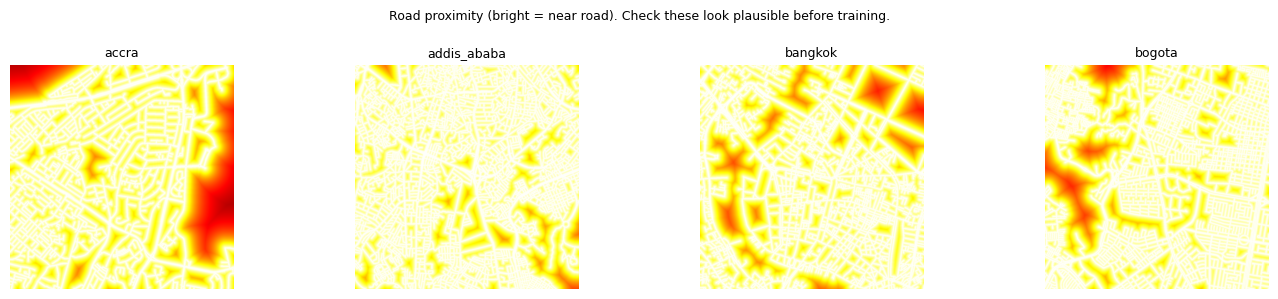

In [2]:
data       = np.load(GROWTH_PATH, allow_pickle=True)
x          = data["x"]               # (N, 7, H, W) uint8 presence 2016–2022
y          = data["y"]               # (N, 1, H, W) uint8 growth mask 2022→2023
city_arr   = data["city"]
split_arr  = data["split"]
metadata   = json.loads(METADATA_PATH.read_text())
presence_stack = np.concatenate([x, data["target_presence"]], axis=1)  # (N, 8, H, W)
year_pair_labels = [f"{s}->{e}" for s, e in zip(YEARS[:-1], YEARS[1:])]

train_idx = np.where(split_arr == "train")[0]
val_idx   = np.where(split_arr == "val")[0]
test_idx  = np.where(split_arr == "test")[0]
print(f"Split — train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")


def _build_road_raster(city_name):
    """Download OSM road network, rasterize, compute proximity map."""
    lat, lon = AOI_CENTERS[city_name]
    try:
        G = ox.graph_from_point((lat, lon), dist=int(HALF_DEG * 111_000 * 1.1),
                                network_type="drive", retain_all=False)
        edges = ox.graph_to_gdfs(G, nodes=False)
    except Exception as e:
        print(f"  {city_name}: OSM failed ({type(e).__name__}), using neutral proximity.")
        return np.full((CITY_IMAGE_SIZE, CITY_IMAGE_SIZE), 0.5, dtype=np.float32)

    west, south, east, north = AOI_BOXES[city_name].bounds
    tf = transform_from_bounds(west, south, east, north, CITY_IMAGE_SIZE, CITY_IMAGE_SIZE)
    geoms = [(geom, 1) for geom in edges.geometry if geom is not None]
    road_mask = rasterio_rasterize(
        geoms, out_shape=(CITY_IMAGE_SIZE, CITY_IMAGE_SIZE),
        transform=tf, fill=0, dtype=np.uint8, all_touched=True,
    )
    dist_px  = distance_transform_edt(1 - road_mask).astype(np.float32)
    meters_per_px = (north - south) * 111_000 / CITY_IMAGE_SIZE
    dist_m   = dist_px * meters_per_px
    return (1.0 / (1.0 + dist_m / ROAD_DECAY_M)).astype(np.float32)


print("Building road proximity rasters (cached after first run)...")
road_rasters = {}
for city_name in tqdm(sorted(AOI_CENTERS.keys()), desc="Cities"):
    cache = ROAD_DIR / f"{city_name}.npy"
    if cache.exists():
        road_rasters[city_name] = np.load(cache)
    else:
        raster = _build_road_raster(city_name)
        np.save(cache, raster)
        road_rasters[city_name] = raster

# Road raster sanity check: binary road network (top) + proximity gradient (bottom)
sample_cities = list(road_rasters.keys())[:4]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for col, c in enumerate(sample_cities):
    prox = road_rasters[c]
    # Binary mask: a pixel is "road" if proximity > threshold (reconstructed from gradient)
    road_bin = (prox >= 0.85).astype(np.float32)   # 1/(1+d/300)>=0.85 → d<=53m ≈ road pixels

    axes[0, col].imshow(road_bin, cmap="gray_r", vmin=0, vmax=1)
    axes[0, col].set_title(c, fontsize=9)
    axes[0, col].axis("off")

    im = axes[1, col].imshow(prox, cmap="YlGn", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Road network\n(black = road)", fontsize=8)
axes[1, 0].set_ylabel("Proximity score\n(green = near road)", fontsize=8)
plt.colorbar(im, ax=axes[1, -1], label="proximity (1=on road, 0=far)", fraction=0.046)
plt.suptitle("Road data from OpenStreetMap. Check roads look realistic for each city.", fontsize=9)
plt.tight_layout()
plt.show()

Enhanced feature function: same 4 channels as before plus road proximity and distance from city centre.

In [3]:
def growth_target_for_pair(sample_idx, pair_idx):
    prev = presence_stack[int(sample_idx), int(pair_idx)] >= 128
    curr = presence_stack[int(sample_idx), int(pair_idx) + 1] >= 128
    return np.logical_and(curr, ~prev).astype(np.uint8) * 255


def enhanced_features_for_pair(sample_idx, pair_idx):
    current = presence_stack[sample_idx, pair_idx] >= 128
    if pair_idx == 0:
        previous_growth = np.zeros_like(current)
    else:
        prev = presence_stack[sample_idx, pair_idx - 1] >= 128
        previous_growth = np.logical_and(current, ~prev)
    edge_zone   = np.logical_and(binary_dilation(current, iterations=MODEL_EDGE_RADIUS), ~current)
    year_ch     = np.full(current.shape, pair_idx / max(len(YEARS) - 2, 1), dtype=np.float32)

    meta        = metadata[sample_idx]
    r, c        = meta["row"], meta["col"]
    road_patch  = road_rasters[meta["city"]][r : r + PATCH_SIZE, c : c + PATCH_SIZE]
    dist_patch  = DIST_FROM_CENTER[r : r + PATCH_SIZE, c : c + PATCH_SIZE]

    return np.stack([
        current.astype(np.float32),
        previous_growth.astype(np.float32),
        edge_zone.astype(np.float32),
        year_ch,
        road_patch,
        dist_patch,
    ], axis=0)  # (6, H, W)


# Baseline 4-channel features (for loading the original model)
def baseline_features_for_pair(sample_idx, pair_idx):
    current = presence_stack[sample_idx, pair_idx] >= 128
    if pair_idx == 0:
        previous_growth = np.zeros_like(current)
    else:
        prev = presence_stack[sample_idx, pair_idx - 1] >= 128
        previous_growth = np.logical_and(current, ~prev)
    edge_zone = np.logical_and(binary_dilation(current, iterations=MODEL_EDGE_RADIUS), ~current)
    year_ch   = np.full(current.shape, pair_idx / max(len(YEARS) - 2, 1), dtype=np.float32)
    return np.stack([
        current.astype(np.float32),
        previous_growth.astype(np.float32),
        edge_zone.astype(np.float32),
        year_ch,
    ], axis=0)  # (4, H, W)


def road_only_features_for_pair(sample_idx, pair_idx):
    """5-channel: original 4 + road proximity only. Used to isolate road contribution."""
    current = presence_stack[sample_idx, pair_idx] >= 128
    if pair_idx == 0:
        previous_growth = np.zeros_like(current)
    else:
        prev = presence_stack[sample_idx, pair_idx - 1] >= 128
        previous_growth = np.logical_and(current, ~prev)
    edge_zone  = np.logical_and(binary_dilation(current, iterations=MODEL_EDGE_RADIUS), ~current)
    year_ch    = np.full(current.shape, pair_idx / max(len(YEARS) - 2, 1), dtype=np.float32)
    meta       = metadata[sample_idx]
    road_patch = road_rasters[meta["city"]][meta["row"] : meta["row"] + PATCH_SIZE,
                                            meta["col"] : meta["col"] + PATCH_SIZE]
    return np.stack([current.astype(np.float32), previous_growth.astype(np.float32),
                     edge_zone.astype(np.float32), year_ch, road_patch], axis=0)  # (5, H, W)


# All feature functions and their model paths in one place
MODEL_SPECS = [
    {"name": "road_only", "label": "+Road only (5ch)",       "in_ch": 5,
     "fn": road_only_features_for_pair,   "path": MODEL_ROAD_PATH},
    {"name": "full",      "label": "+Road +Centre (6ch)",    "in_ch": 6,
     "fn": enhanced_features_for_pair,    "path": MODEL_FULL_PATH},
]

print("Feature check:")
f5 = road_only_features_for_pair(train_idx[0], 3)
f6 = enhanced_features_for_pair(train_idx[0], 3)
print(f"  5-channel shape: {f5.shape}  |  6-channel shape: {f6.shape}")
print(f"  Road channel (ch4) — mean: {f6[4].mean():.3f}")
print(f"  Centre-dist  (ch5) — mean: {f6[5].mean():.3f}")

Feature check:
  5-channel shape: (5, 128, 128)  |  6-channel shape: (6, 128, 128)
  Road channel (ch4) — mean: 0.737
  Centre-dist  (ch5) — mean: 0.516


Rolling training index, model architecture, and training loop. Identical to the original growth notebook except `in_channels=6`.

In [7]:
def make_rolling_index():
    rows = []
    for si in range(len(presence_stack)):
        for pi, label in enumerate(year_pair_labels):
            tgt = growth_target_for_pair(si, pi)
            gs  = float((tgt >= 128).mean())
            rows.append({
                "sample_id": si, "pair_idx": pi,
                "year_pair": label, "split": split_arr[si],
                "growth_pixel_share": gs,
                "has_growth": bool(gs >= MIN_GROWTH_SHARE),
                "is_final_pair": label == "2022->2023",
            })
    return pd.DataFrame(rows)


def balance_training_rows(rows_df, positive_ratio=0.55):
    balanced = []
    lrng = np.random.default_rng(SEED)
    for _, group in rows_df.groupby(["split", "year_pair"]):
        pos = group[group["has_growth"]]
        neg = group[~group["has_growth"]]
        if len(pos) == 0 or len(neg) == 0:
            balanced.append(group.sample(min(len(group), 60), random_state=SEED))
            continue
        pk = min(len(pos), int(np.ceil(len(neg) * positive_ratio / (1 - positive_ratio))))
        balanced.extend([neg, pos.sample(pk, random_state=SEED)])
    out = pd.concat(balanced, ignore_index=True)
    return out.iloc[lrng.permutation(len(out))].reset_index(drop=True)


rolling_df    = make_rolling_index()
train_roll_df = balance_training_rows(rolling_df[rolling_df["split"] == "train"])
val_roll_df   = rolling_df[(rolling_df["split"] == "val")  & ~rolling_df["is_final_pair"]].reset_index(drop=True)
test_final_df = rolling_df[(rolling_df["split"] == "test") &  rolling_df["is_final_pair"]].reset_index(drop=True)

print(f"Train rolling rows: {len(train_roll_df):,}  |  val rows: {len(val_roll_df):,}  |  test final: {len(test_final_df):,}")


class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class SmallUNet(nn.Module):
    """Layer names match the training notebook exactly so saved weights load correctly."""
    def __init__(self, in_channels, base=24):
        super().__init__()
        self.enc1       = ConvBlock(in_channels, base)
        self.enc2       = ConvBlock(base, base * 2)
        self.bottleneck = ConvBlock(base * 2, base * 4)
        self.up2        = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2       = ConvBlock(base * 4, base * 2)
        self.up1        = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1       = ConvBlock(base * 2, base)
        self.out        = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        b  = self.bottleneck(F.max_pool2d(e2, 2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)


n4 = sum(p.numel() for p in SmallUNet(4).parameters())
n6 = sum(p.numel() for p in SmallUNet(6).parameters())
print(f"Baseline (4ch): {n4:,} params  |  Enhanced (6ch): {n6:,} params  (diff: {n6-n4:,})")

Train rolling rows: 1,775  |  val rows: 2,880  |  test final: 450
Baseline (4ch): 263,905 params  |  Enhanced (6ch): 264,337 params  (diff: 432)


Train the enhanced model on the rolling year-pair dataset. Skips training if the saved model already exists.

Positive pixel rate (sample): 2.26%  |  pos_weight: 6.58

Training: +Road only (5ch)
  ep 01 | train 1.3923 | val 1.3473
  ep 05 | train 1.0051 | val 1.0494
  ep 10 | train 0.8770 | val 0.9465
  ep 15 | train 0.8376 | val 0.9043
  ep 20 | train 0.8084 | val 0.8799
  ep 25 | train 0.7799 | val 0.8689
  ep 30 | train 0.7502 | val 0.8938

Training: +Road +Centre (6ch)
  ep 01 | train 1.2387 | val 1.2215
  ep 05 | train 0.9302 | val 0.9903
  ep 10 | train 0.8500 | val 0.9002
  ep 15 | train 0.8154 | val 0.8800
  ep 20 | train 0.7801 | val 0.8820
  ep 25 | train 0.7406 | val 0.8795
  Early stop. Best: ep 19 | val 0.8695


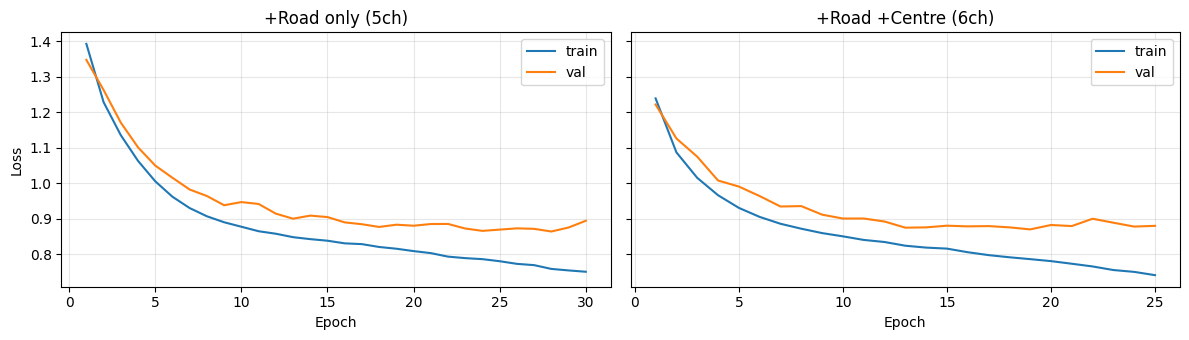

In [8]:
EPOCHS   = 30
PATIENCE = 6
MIN_DELTA = 1e-4
BATCH    = 16
LR       = 3e-4


class GrowthDataset(Dataset):
    def __init__(self, rows_df, feature_fn):
        self.rows = rows_df.reset_index(drop=True)
        self.feature_fn = feature_fn

    def __len__(self): return len(self.rows)

    def __getitem__(self, i):
        row = self.rows.iloc[i]
        xb  = torch.from_numpy(self.feature_fn(int(row["sample_id"]), int(row["pair_idx"])))
        yb  = torch.from_numpy(
            growth_target_for_pair(int(row["sample_id"]), int(row["pair_idx"]))
            .astype(np.float32)[None] / 255.0
        )
        return xb, yb


def tversky_loss(logits, target, alpha=0.75, beta=0.25, smooth=1.0):
    p = torch.sigmoid(logits)
    tp = (p * target).sum(dim=(1, 2, 3))
    fp = (p * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - p) * target).sum(dim=(1, 2, 3))
    return (1 - ((tp + smooth) / (tp + alpha * fp + beta * fn + smooth))).mean()


pos_ratio = float((growth_target_for_pair(train_roll_df.iloc[0]["sample_id"],
                                          train_roll_df.iloc[0]["pair_idx"]) >= 128).mean())
# Compute pos_ratio properly from training targets
sample_targets = np.array([(growth_target_for_pair(r.sample_id, r.pair_idx) >= 128).mean()
                            for r in train_roll_df.sample(200, random_state=SEED).itertuples()])
pos_ratio = float(sample_targets.mean())
pos_w     = float(np.clip(np.sqrt((1 - pos_ratio) / max(pos_ratio, 1e-6)), 1.0, 8.0))
bce_loss  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_w, device=device))
print(f"Positive pixel rate (sample): {pos_ratio:.2%}  |  pos_weight: {pos_w:.2f}")


def criterion(logits, target):
    return bce_loss(logits, target) + 0.7 * tversky_loss(logits, target)


def run_epoch(model, dl, opt=None):
    model.train(opt is not None)
    losses = []
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        if opt:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def train_or_load(spec):
    torch.manual_seed(SEED)
    if spec["path"].exists():
        ckpt = torch.load(spec["path"], map_location=device, weights_only=False)
        mdl  = SmallUNet(spec["in_ch"]).to(device)
        mdl.load_state_dict(ckpt["state"])
        mdl.eval()
        best = min(ckpt["history"], key=lambda r: r["val"])
        print(f"Loaded: {spec['label']}  (best ep {best['epoch']:02d} | val {best['val']:.4f})")
        return mdl, ckpt["history"]

    print(f"\nTraining: {spec['label']}")
    mdl   = SmallUNet(spec["in_ch"]).to(device)
    opt   = torch.optim.AdamW(mdl.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=2)
    dl_tr = DataLoader(GrowthDataset(train_roll_df, spec["fn"]),
                       BATCH, shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))
    dl_vl = DataLoader(GrowthDataset(val_roll_df, spec["fn"]),
                       BATCH, shuffle=False, num_workers=0)

    history, best_loss, stalls = [], float("inf"), 0
    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch(mdl, dl_tr, opt)
        vl = run_epoch(mdl, dl_vl)
        sched.step(vl)
        history.append({"epoch": epoch, "train": tr, "val": vl})
        if epoch == 1 or epoch % 5 == 0:
            print(f"  ep {epoch:02d} | train {tr:.4f} | val {vl:.4f}")
        if vl < best_loss - MIN_DELTA:
            best_loss, stalls = vl, 0
            torch.save({"state": mdl.state_dict(), "history": history}, spec["path"])
        else:
            stalls += 1
            if stalls >= PATIENCE:
                best = min(history, key=lambda r: r["val"])
                print(f"  Early stop. Best: ep {best['epoch']:02d} | val {best['val']:.4f}")
                break
    mdl.load_state_dict(torch.load(spec["path"], map_location=device, weights_only=False)["state"])
    mdl.eval()
    return mdl, history


trained_models = {}
all_histories  = {}
for spec in MODEL_SPECS:
    trained_models[spec["name"]], all_histories[spec["name"]] = train_or_load(spec)

# Training curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, spec in zip(axes, MODEL_SPECS):
    h = pd.DataFrame(all_histories[spec["name"]])
    ax.plot(h["epoch"], h["train"], label="train")
    ax.plot(h["epoch"], h["val"],   label="val")
    ax.set_title(spec["label"])
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
plt.tight_layout()
plt.show()

Evaluate both models on the held-out 2022→2023 test set. PR-AUC is the primary metric — it measures ranking quality across all probability thresholds.

In [11]:
def average_precision(scores_float, targets_uint8):
    y_true  = (targets_uint8 >= 128).ravel().astype(bool)
    y_score = scores_float.ravel().astype(np.float64)
    if not y_true.any():
        return np.nan
    order   = np.argsort(-y_score, kind="mergesort")
    y_true  = y_true[order]; y_score = y_score[order]
    tidxs   = np.r_[np.where(np.diff(y_score))[0], y_true.size - 1]
    tp      = np.cumsum(y_true)[tidxs]
    prec    = tp / (tidxs + 1)
    rec     = tp / y_true.sum()
    return float(np.sum(np.diff(np.r_[0.0, rec]) * prec))


def predict_scores(mdl, rows_df, feature_fn, batch=32):
    dl = DataLoader(GrowthDataset(rows_df, feature_fn), batch, shuffle=False, num_workers=0)
    probs = []
    mdl.eval()
    with torch.no_grad():
        for xb, _ in dl:
            probs.append(torch.sigmoid(mdl(xb.to(device))).cpu().numpy())
    return np.concatenate(probs)


def targets_for_rows(rows_df):
    return np.stack([growth_target_for_pair(int(r.sample_id), int(r.pair_idx))
                     for r in rows_df.itertuples(index=False)])[:, None]


def edge_baseline_scores(rows_df, radius=8):
    """Simple geometric baseline: score = proximity to existing buildings."""
    scores = []
    for row in rows_df.itertuples(index=False):
        existing = presence_stack[int(row.sample_id), int(row.pair_idx)] >= 128
        if existing.any():
            dist  = distance_transform_edt(~existing).astype(np.float32)
            score = 1.0 / (1.0 + dist)
            score[existing] = 0.0
        else:
            score = np.zeros(existing.shape, dtype=np.float32)
        scores.append(score)
    return np.stack(scores)[:, None]


test_targets = targets_for_rows(test_final_df)

# --- Geometric baseline (no ML) ---
edge_scores  = edge_baseline_scores(test_final_df)
auc_edge     = average_precision(edge_scores, test_targets)

# --- Original 4-channel DL model ---
auc_original = np.nan
if BASELINE_PATH.exists():
    orig_mdl = SmallUNet(4).to(device)
    ckpt     = torch.load(BASELINE_PATH, map_location=device, weights_only=False)
    # key might be "model_state_dict" (training notebook) or "state" (height notebook)
    state_key = "model_state_dict" if "model_state_dict" in ckpt else "state"
    orig_mdl.load_state_dict(ckpt[state_key])
    orig_mdl.eval()
    probs_orig   = predict_scores(orig_mdl, test_final_df, baseline_features_for_pair)
    auc_original = average_precision(probs_orig * 255, test_targets)

# --- Ablation models ---
all_probs = {}   # saved for PR-AUC curves and feature analysis below
if BASELINE_PATH.exists():
    all_probs["Original UNet (4ch)"] = probs_orig

results = []
for spec in MODEL_SPECS:
    mdl   = trained_models[spec["name"]]
    probs = predict_scores(mdl, test_final_df, spec["fn"])
    all_probs[spec["label"]] = probs
    results.append({"label": spec["label"], "in_ch": spec["in_ch"],
                    "pr_auc": average_precision(probs * 255, test_targets)})

SEP = "─" * 68
print("ABLATION TABLE  —  2022→2023 growth, 5 held-out cities")
print("Each row adds exactly one component over the row above it.")
print(SEP)
print(f"  {'Model':<44}  {'Channels':>9}  {'PR-AUC':>7}")
print(SEP)
print(f"  {'Nearest-building edge (no ML)':<44}  {'—':>9}  {auc_edge:>7.3f}")
if not np.isnan(auc_original):
    print(f"  {'Original UNet  (presence, growth, edge, year)':<44}  {'4':>9}  {auc_original:>7.3f}")
else:
    print(f"  {'Original UNet  (from training notebook)':<44}  {'4':>9}  {'~0.303':>7}")
for r in results:
    print(f"  {r['label']:<44}  {r['in_ch']:>9}  {r['pr_auc']:>7.3f}")
print(SEP)

# Print what the table shows
ref = auc_original if not np.isnan(auc_original) else 0.303
for r in results:
    delta = r["pr_auc"] - ref
    tag   = "↑ improves" if delta > 0.005 else ("↓ hurts" if delta < -0.005 else "→ no change")
    print(f"  {r['label']}: {delta:+.3f} vs original  ({tag})")

ABLATION TABLE  —  2022→2023 growth, 5 held-out cities
Each row adds exactly one component over the row above it.
────────────────────────────────────────────────────────────────────
  Model                                          Channels   PR-AUC
────────────────────────────────────────────────────────────────────
  Nearest-building edge (no ML)                         —    0.156
  Original UNet  (presence, growth, edge, year)          4    0.309
  +Road only (5ch)                                      5    0.314
  +Road +Centre (6ch)                                   6    0.319
────────────────────────────────────────────────────────────────────
  +Road only (5ch): +0.005 vs original  (↑ improves)
  +Road +Centre (6ch): +0.010 vs original  (↑ improves)


## PR-AUC Curves and Feature Contribution

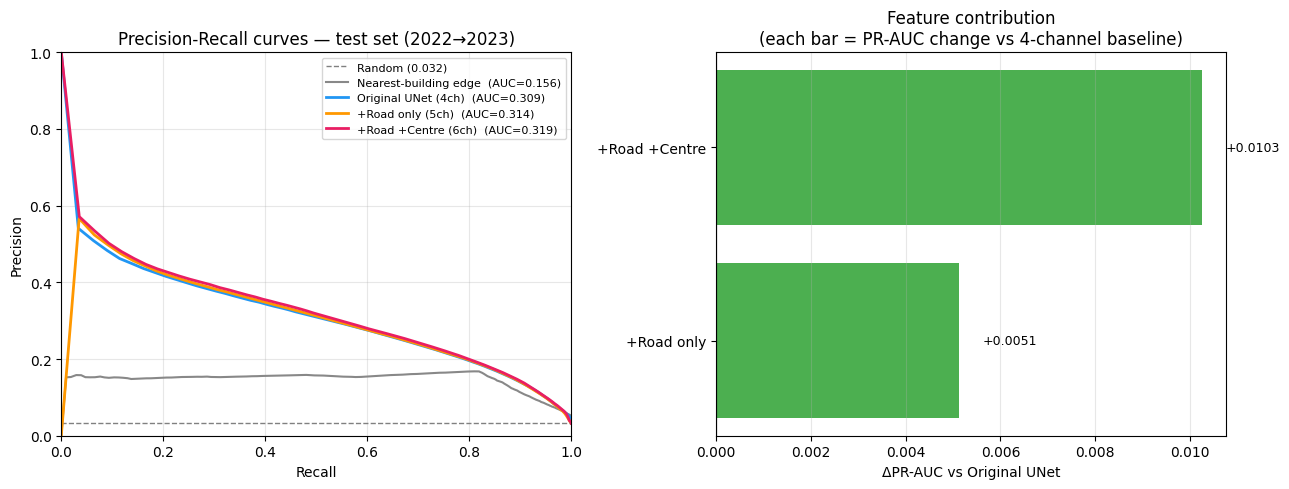

In [12]:
def pr_curve(scores_float, targets_uint8):
    y_true  = (targets_uint8 >= 128).ravel().astype(bool)
    y_score = scores_float.ravel().astype(np.float64)
    order   = np.argsort(-y_score, kind="mergesort")
    y_true  = y_true[order]
    tp  = np.cumsum(y_true)
    fp  = np.cumsum(~y_true)
    rec = tp / y_true.sum()
    pre = tp / (tp + fp)
    # subsample to 500 points for plotting speed
    idx = np.unique(np.linspace(0, len(rec) - 1, 500).astype(int))
    return rec[idx], pre[idx]


# ── PR-AUC curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
random_precision = float((test_targets >= 128).mean())
ax.axhline(random_precision, color="gray", lw=1, ls="--",
           label=f"Random ({random_precision:.3f})")

model_colors = {"Nearest-building edge": "#888888",
                "Original UNet (4ch)":   "#2196F3",
                "+Road only (5ch)":      "#FF9800",
                "+Road +Centre (6ch)":   "#E91E63"}

# geometric baseline
auc_e = average_precision(edge_scores, test_targets)
rec_e, pre_e = pr_curve(edge_scores, test_targets)
ax.plot(rec_e, pre_e, color=model_colors["Nearest-building edge"],
        lw=1.5, label=f"Nearest-building edge  (AUC={auc_e:.3f})")

for label, probs in all_probs.items():
    auc  = average_precision(probs * 255, test_targets)
    rec, pre = pr_curve(probs * 255, test_targets)
    color = model_colors.get(label, "#333333")
    ax.plot(rec, pre, color=color, lw=2, label=f"{label}  (AUC={auc:.3f})")

ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1),
       title="Precision-Recall curves — test set (2022→2023)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)


# ── Feature contribution bar chart ────────────────────────────────────────
ref_auc = average_precision(all_probs.get("Original UNet (4ch)", edge_scores) * 255, test_targets) \
          if "Original UNet (4ch)" in all_probs else np.nan

ax2 = axes[1]
labels_delta, deltas, colors_delta = [], [], []
for label, probs in all_probs.items():
    if label == "Original UNet (4ch)":
        continue
    delta = average_precision(probs * 255, test_targets) - (ref_auc if not np.isnan(ref_auc) else 0)
    labels_delta.append(label.replace(" (5ch)", "").replace(" (6ch)", ""))
    deltas.append(delta)
    colors_delta.append("#4CAF50" if delta > 0 else "#F44336")

bars = ax2.barh(labels_delta, deltas, color=colors_delta)
ax2.axvline(0, color="black", lw=0.8)
ax2.set(xlabel="ΔPR-AUC vs Original UNet",
        title="Feature contribution\n(each bar = PR-AUC change vs 4-channel baseline)")
for bar, d in zip(bars, deltas):
    ax2.text(d + 0.0005 * np.sign(d), bar.get_y() + bar.get_height() / 2,
             f"{d:+.4f}", va="center", ha="left" if d >= 0 else "right", fontsize=9)
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## Direction of Feature Effects

Does road proximity actually correlate with more or less growth? Does being further from the city centre mean more or less growth? These plots show the relationship — so the model's use of these features can be interpreted.

Each point is one test patch. X-axis = the feature's mean value for non-built pixels. Y-axis = the fraction of those pixels that became new buildings.

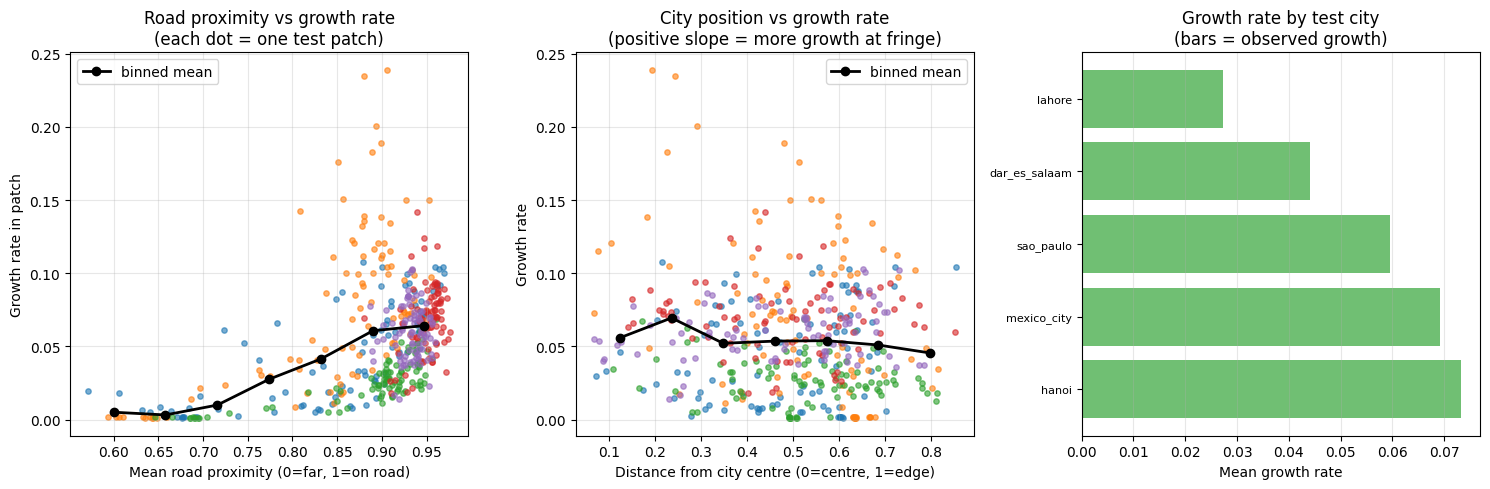

Correlation with growth rate (Pearson r):
  Road proximity:      +0.480
  Dist from centre:    -0.106

Interpretation:
  + correlation with road proximity = patches near roads grow faster
  + correlation with dist from centre = more growth at city fringes (sprawl pattern)
  - correlation with dist from centre = more growth in city cores (densification pattern)


In [13]:
patch_stats = []
for row in test_final_df.itertuples(index=False):
    si, pi = int(row.sample_id), int(row.pair_idx)
    feat6  = enhanced_features_for_pair(si, pi)
    built  = feat6[0] >= 0.5
    tgt    = (growth_target_for_pair(si, pi) >= 128)
    cand   = ~built   # candidate pixels (currently empty)
    if cand.sum() < 10:
        continue
    patch_stats.append({
        "city":           city_arr[si],
        "growth_rate":    float(tgt[cand].mean()),
        "road_proximity": float(feat6[4][cand].mean()),
        "dist_centre":    float(feat6[5][cand].mean()),
    })
ps_df = pd.DataFrame(patch_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: road proximity vs growth rate
ax = axes[0]
for city_name, group in ps_df.groupby("city"):
    ax.scatter(group["road_proximity"], group["growth_rate"], s=15, alpha=0.6)
# Binned trend
bins = np.linspace(ps_df["road_proximity"].min(), ps_df["road_proximity"].max(), 8)
ps_df["road_bin"] = pd.cut(ps_df["road_proximity"], bins)
trend = ps_df.groupby("road_bin", observed=True)["growth_rate"].mean()
bin_centres = [(iv.left + iv.right) / 2 for iv in trend.index]
ax.plot(bin_centres, trend.values, "k-o", lw=2, ms=6, label="binned mean")
ax.set(xlabel="Mean road proximity (0=far, 1=on road)", ylabel="Growth rate in patch",
       title="Road proximity vs growth rate\n(each dot = one test patch)")
ax.legend()
ax.grid(True, alpha=0.3)

# Middle: distance from centre vs growth rate
ax = axes[1]
for city_name, group in ps_df.groupby("city"):
    ax.scatter(group["dist_centre"], group["growth_rate"], s=15, alpha=0.6)
bins2 = np.linspace(ps_df["dist_centre"].min(), ps_df["dist_centre"].max(), 8)
ps_df["dist_bin"] = pd.cut(ps_df["dist_centre"], bins2)
trend2 = ps_df.groupby("dist_bin", observed=True)["growth_rate"].mean()
bin_centres2 = [(iv.left + iv.right) / 2 for iv in trend2.index]
ax.plot(bin_centres2, trend2.values, "k-o", lw=2, ms=6, label="binned mean")
ax.set(xlabel="Distance from city centre (0=centre, 1=edge)", ylabel="Growth rate",
       title="City position vs growth rate\n(positive slope = more growth at fringe)")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: per-city summary — does road proximity rank cities correctly?
ax = axes[2]
city_summary = ps_df.groupby("city")[["road_proximity", "dist_centre", "growth_rate"]].mean().reset_index()
city_summary = city_summary.sort_values("growth_rate", ascending=False)
y_pos = np.arange(len(city_summary))
ax.barh(y_pos, city_summary["growth_rate"], color="#4CAF50", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(city_summary["city"], fontsize=8)
ax.set(xlabel="Mean growth rate", title="Growth rate by test city\n(bars = observed growth)")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("Correlation with growth rate (Pearson r):")
print(f"  Road proximity:      {ps_df['road_proximity'].corr(ps_df['growth_rate']):+.3f}")
print(f"  Dist from centre:    {ps_df['dist_centre'].corr(ps_df['growth_rate']):+.3f}")
print()
print("Interpretation:")
print("  + correlation with road proximity = patches near roads grow faster")
print("  + correlation with dist from centre = more growth at city fringes (sprawl pattern)")
print("  - correlation with dist from centre = more growth in city cores (densification pattern)")

## Training Improvement Check

**What the current training does well:**
- Rolling year pairs → 7× more training examples than static 2022→2023 only
- BCE + Tversky loss with pos_weight → handles the 3.5% positive rate
- Early stopping + ReduceLROnPlateau → stops before overfitting
- Seeded DataLoader → reproducibility

**One realistic improvement that's currently missing: data augmentation.**

The GrowthDataset applies no geometric transformations. Random horizontal and vertical flips are free (zero extra data downloads), double or quadruple effective dataset size, and are standard practice in segmentation. Growth patterns are spatially isotropic (new buildings appear in all directions), so flipping is semantically valid.

Everything else has essentially been explored:
- Larger architecture (ResNet34 tested in the training notebook — no improvement)
- More cities (25 already, adding more requires GCS tile downloads)
- Temporal context (tested with rolling pairs — 7 years is already used)

**Impact estimate:** data augmentation typically adds 2–5 F1 points in remote-sensing segmentation. Given we're at PR-AUC ~0.31, this could push toward 0.33–0.34. Not a transformation but meaningful.

The cell below implements it as a toggle — set `USE_AUGMENTATION = True` to retrain with flips.

In [14]:
USE_AUGMENTATION = True   # set True to retrain with random flips

AUG_MODEL_PATH = MODEL_DIR / f"rolling_unet_aug_{HASH}.pt"


class AugGrowthDataset(GrowthDataset):
    """Same as GrowthDataset but applies random horizontal/vertical flips."""
    def __getitem__(self, i):
        xb, yb = super().__getitem__(i)
        if torch.rand(1).item() > 0.5:
            xb = torch.flip(xb, dims=[-1])
            yb = torch.flip(yb, dims=[-1])
        if torch.rand(1).item() > 0.5:
            xb = torch.flip(xb, dims=[-2])
            yb = torch.flip(yb, dims=[-2])
        return xb, yb


if USE_AUGMENTATION:
    aug_spec = {
        "name": "aug", "label": "+Road +Centre +Augmentation (6ch)",
        "in_ch": 6, "fn": enhanced_features_for_pair, "path": AUG_MODEL_PATH,
    }
    # Train using augmented dataset
    if AUG_MODEL_PATH.exists():
        aug_ckpt = torch.load(AUG_MODEL_PATH, map_location=device, weights_only=False)
        aug_model = SmallUNet(6).to(device)
        aug_model.load_state_dict(aug_ckpt["state"])
        aug_model.eval()
        print(f"Loaded augmented model.")
    else:
        torch.manual_seed(SEED)
        aug_model = SmallUNet(6).to(device)
        opt  = torch.optim.AdamW(aug_model.parameters(), lr=LR, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=2)
        dl_tr = DataLoader(AugGrowthDataset(train_roll_df, enhanced_features_for_pair),
                           BATCH, shuffle=True, num_workers=0,
                           generator=torch.Generator().manual_seed(SEED))
        dl_vl = DataLoader(GrowthDataset(val_roll_df, enhanced_features_for_pair),
                           BATCH, shuffle=False, num_workers=0)
        history_aug, best_loss, stalls = [], float("inf"), 0
        print("Training: +Augmentation (random flips)")
        for epoch in range(1, EPOCHS + 1):
            tr = run_epoch(aug_model, dl_tr, opt)
            vl = run_epoch(aug_model, dl_vl)
            sched.step(vl)
            history_aug.append({"epoch": epoch, "train": tr, "val": vl})
            if epoch == 1 or epoch % 5 == 0:
                print(f"  ep {epoch:02d} | train {tr:.4f} | val {vl:.4f}")
            if vl < best_loss - MIN_DELTA:
                best_loss, stalls = vl, 0
                torch.save({"state": aug_model.state_dict(), "history": history_aug}, AUG_MODEL_PATH)
            else:
                stalls += 1
                if stalls >= PATIENCE:
                    best = min(history_aug, key=lambda r: r["val"])
                    print(f"  Early stop. Best: ep {best['epoch']:02d} | val {best['val']:.4f}")
                    break
        aug_model.load_state_dict(torch.load(AUG_MODEL_PATH, map_location=device, weights_only=False)["state"])
        aug_model.eval()

    aug_probs = predict_scores(aug_model, test_final_df, enhanced_features_for_pair)
    aug_auc   = average_precision(aug_probs * 255, test_targets)
    full_auc  = average_precision(all_probs["+Road +Centre (6ch)"] * 255, test_targets)
    print(f"+Road +Centre (no augmentation): PR-AUC = {full_auc:.4f}")
    print(f"+Road +Centre + augmentation:    PR-AUC = {aug_auc:.4f}  (Δ = {aug_auc - full_auc:+.4f})")
else:
    print("USE_AUGMENTATION = False. Set to True and re-run to test data augmentation.")

Training: +Augmentation (random flips)
  ep 01 | train 1.2381 | val 1.2269
  ep 05 | train 0.9343 | val 0.9987
  ep 10 | train 0.8569 | val 0.9300
  ep 15 | train 0.8262 | val 0.9038
  ep 20 | train 0.7997 | val 0.8951
  ep 25 | train 0.7856 | val 0.8979
  ep 30 | train 0.7777 | val 0.8970
  Early stop. Best: ep 24 | val 0.8882
+Road +Centre (no augmentation): PR-AUC = 0.3191
+Road +Centre + augmentation:    PR-AUC = 0.3168  (Δ = -0.0024)


## WorldPop Population Density Feature

Population density is a well-established predictor of urban growth in the literature. This section adds WorldPop 2020 100m constrained population data as a 7th input channel.

Data is streamed from `data.worldpop.org` using the same windowed-read approach as the Open Buildings tiles — only the bounding box for each city is downloaded, not the full country file. Requires one HTTP read per city (~1-3 seconds each).

In [16]:
POP_DIR   = CACHE_DIR / "pop_rasters"
POP_DIR.mkdir(parents=True, exist_ok=True)
POP_MODEL_PATH = MODEL_DIR / f"rolling_unet_pop_{HASH}.pt"


_WP_IMAGE_SERVER = (
    "https://worldpop.arcgis.com/arcgis/rest/services/"
    "WorldPop_Population_Density_100m/ImageServer/exportImage"
)
_WP_TIME_2020 = "1577836800000"  # 2020-01-01 in milliseconds


def load_worldpop_raster(city_name):
    cache = POP_DIR / f"{city_name}.npy"
    if cache.exists() and np.load(cache).max() > 0:
        return np.load(cache)
    west, south, east, north = AOI_BOXES[city_name].bounds
    params = {
        "bbox": f"{west},{south},{east},{north}",
        "bboxSR": "4326", "imageSR": "4326",
        "size": f"{CITY_IMAGE_SIZE},{CITY_IMAGE_SIZE}",
        "time": _WP_TIME_2020,
        "format": "tiff", "pixelType": "F32", "f": "image",
    }
    try:
        import requests as _req
        from rasterio.io import MemoryFile
        r = _req.get(_WP_IMAGE_SERVER, params=params, timeout=30)
        r.raise_for_status()
        with MemoryFile(r.content) as mf:
            with mf.open() as src:
                arr = src.read(1).astype(np.float32)
        pop = np.maximum(arr, 0.0)
        pop_norm = (np.log1p(pop) / np.log1p(pop.max() + 1e-6)).astype(np.float32)
    except Exception as e:
        print(f"  {city_name}: WorldPop failed ({type(e).__name__}: {e}), using zeros.")
        pop_norm = np.zeros((CITY_IMAGE_SIZE, CITY_IMAGE_SIZE), dtype=np.float32)
    np.save(cache, pop_norm)
    return pop_norm


print("Loading WorldPop rasters (streams only city window, ~1-3s per city)...")
pop_rasters = {}
for city_name in tqdm(sorted(AOI_CENTERS.keys()), desc="Cities"):
    pop_rasters[city_name] = load_worldpop_raster(city_name)

print(f"\nLoaded {len(pop_rasters)} city population rasters.")
non_zero = [c for c, r in pop_rasters.items() if r.max() > 0]
print(f"Cities with non-zero population data: {len(non_zero)}/25")

Loading WorldPop rasters (streams only city window, ~1-3s per city)...


Cities:   0%|          | 0/25 [00:00<?, ?it/s]


Loaded 25 city population rasters.
Cities with non-zero population data: 25/25


In [17]:
def pop_features_for_pair(sample_idx, pair_idx):
    """7-channel: original 4 + road + centre + population density."""
    feat6 = enhanced_features_for_pair(sample_idx, pair_idx)
    meta  = metadata[sample_idx]
    r, c  = meta["row"], meta["col"]
    pop_patch = pop_rasters[meta["city"]][r : r + PATCH_SIZE, c : c + PATCH_SIZE]
    return np.concatenate([feat6, pop_patch[np.newaxis]], axis=0)  # (7, H, W)


pop_spec = {
    "name": "pop", "label": "+Road +Centre +Population (7ch)",
    "in_ch": 7, "fn": pop_features_for_pair, "path": POP_MODEL_PATH,
}
pop_model, pop_history = train_or_load(pop_spec)

pop_probs = predict_scores(pop_model, test_final_df, pop_features_for_pair)
pop_auc   = average_precision(pop_probs * 255, test_targets)
full_auc  = average_precision(all_probs.get("+Road +Centre (6ch)", np.zeros_like(pop_probs)) * 255, test_targets)

print(f"\n+Road +Centre          (6ch): PR-AUC = {full_auc:.4f}")
print(f"+Road +Centre +Pop     (7ch): PR-AUC = {pop_auc:.4f}  (Δ = {pop_auc - full_auc:+.4f})")
if pop_auc - full_auc > 0.005:
    print("→ Population density adds meaningful signal. Proceed to a combined best model.")
elif pop_auc - full_auc > -0.005:
    print("→ Population density adds no meaningful signal at this patch scale (100m data for 512m patches).")
else:
    print("→ Population density slightly hurts. May be adding noise — data quality may vary by city.")


Training: +Road +Centre +Population (7ch)
  ep 01 | train 1.3035 | val 1.2699
  ep 05 | train 0.9455 | val 0.9851
  ep 10 | train 0.8532 | val 0.9065
  ep 15 | train 0.8173 | val 0.8740
  ep 20 | train 0.7771 | val 0.8906
  Early stop. Best: ep 16 | val 0.8674

+Road +Centre          (6ch): PR-AUC = 0.3191
+Road +Centre +Pop     (7ch): PR-AUC = 0.3152  (Δ = -0.0039)
→ Population density adds no meaningful signal at this patch scale (100m data for 512m patches).


Visualise what the road proximity channel looks like alongside the model's predictions.

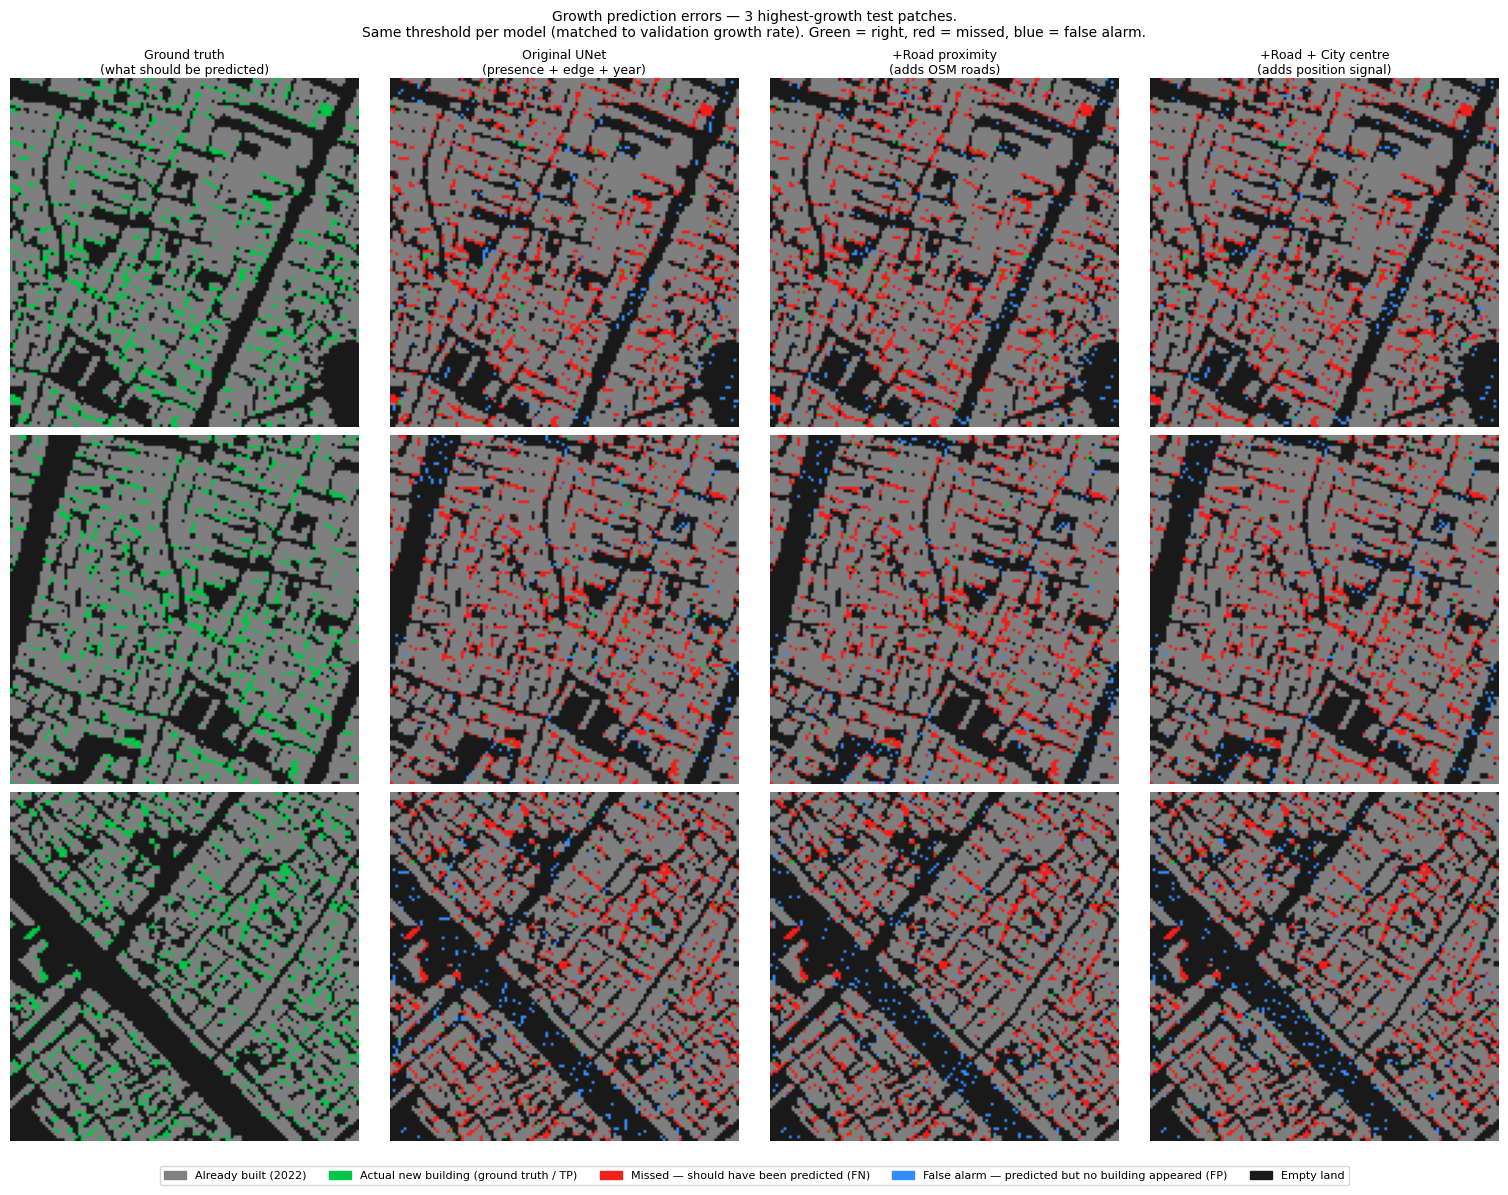

In [18]:
C_EMPTY    = np.array([0.10, 0.10, 0.10])   # empty land — dark
C_EXISTING = np.array([0.50, 0.50, 0.50])   # already built — grey
C_GT_NEW   = np.array([0.00, 0.78, 0.28])   # actual new building — green
C_TP       = np.array([0.00, 0.78, 0.28])   # correct prediction — green
C_FN       = np.array([0.95, 0.12, 0.10])   # missed growth — red
C_FP       = np.array([0.20, 0.55, 1.00])   # false alarm — blue


def ground_truth_rgb(existing, new_growth):
    rgb = np.full((*existing.shape, 3), C_EMPTY, dtype=np.float32)
    rgb[existing]  = C_EXISTING
    rgb[new_growth] = C_GT_NEW
    return rgb


def error_rgb(existing, target, pred):
    rgb = np.full((*existing.shape, 3), C_EMPTY, dtype=np.float32)
    rgb[existing]               = C_EXISTING
    rgb[target &  pred]         = C_TP
    rgb[target & ~pred]         = C_FN
    rgb[~target & ~existing & pred] = C_FP
    return rgb


def threshold_from_val(probs, rows_df, target_rate):
    """Pick threshold so predicted-positive rate matches validation growth rate."""
    flat = probs.ravel()
    k = int(round(target_rate * len(flat)))
    return float(np.partition(flat, -k)[-k]) if k > 0 else 0.5


# Pick the 3 test patches with the most actual growth across all test cities
all_test_rows = [(row, float((growth_target_for_pair(int(row.sample_id), int(row.pair_idx)) >= 128).mean()))
                 for row in test_final_df.itertuples(index=False)]
all_test_rows.sort(key=lambda t: t[1], reverse=True)
vis_rows = [t[0] for t in all_test_rows[:3]]

# Collect all model predictions for the visualisation patches
vis_df     = test_final_df[test_final_df["sample_id"].isin([int(r.sample_id) for r in vis_rows])].head(3)
val_growth_rate = float(val_roll_df["growth_pixel_share"].mean())

# Load baseline model predictions (needed for vis)
all_vis_probs = {}
if BASELINE_PATH.exists():
    _bm = SmallUNet(4).to(device)
    _ck = torch.load(BASELINE_PATH, map_location=device, weights_only=False)
    _bm.load_state_dict(_ck["model_state_dict"])
    _bm.eval()
    all_vis_probs["original"]  = predict_scores(_bm, vis_df, baseline_features_for_pair)
all_vis_probs["road_only"] = predict_scores(trained_models["road_only"],  vis_df, road_only_features_for_pair)
all_vis_probs["full"]      = predict_scores(trained_models["full"],       vis_df, enhanced_features_for_pair)

MODEL_VIS_SPECS = [
    ("ground_truth", "Ground truth\n(what should be predicted)"),
    ("original",     "Original UNet\n(presence + edge + year)"),
    ("road_only",    "+Road proximity\n(adds OSM roads)"),
    ("full",         "+Road + City centre\n(adds position signal)"),
]

n = len(vis_rows)
n_cols = len(MODEL_VIS_SPECS)
fig, axes = plt.subplots(n, n_cols, figsize=(3.8 * n_cols, 3.8 * n), constrained_layout=True)
if n == 1:
    axes = axes[np.newaxis]

for ri, row in enumerate(vis_rows):
    si, pi = int(row.sample_id), int(row.pair_idx)
    existing = presence_stack[si, pi] >= 128
    new_growth = (growth_target_for_pair(si, pi) >= 128)
    city_label = city_arr[si]

    for ci, (key, col_title) in enumerate(MODEL_VIS_SPECS):
        ax = axes[ri, ci]
        if key == "ground_truth":
            img = ground_truth_rgb(existing, new_growth)
        elif key in all_vis_probs:
            local_i = [int(r.sample_id) for r in vis_rows].index(si)
            prob_map = all_vis_probs[key][local_i, 0]
            thr = threshold_from_val(prob_map, vis_df, val_growth_rate)
            pred = prob_map >= thr
            img = error_rgb(existing, new_growth, pred)
        else:
            ax.axis("off")
            continue

        ax.imshow(img)
        ax.axis("off")
        if ri == 0:
            ax.set_title(col_title, fontsize=9, pad=4)
        if ci == 0:
            ax.set_ylabel(city_label, fontsize=9)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color=C_EXISTING, label="Already built (2022)"),
    Patch(color=C_GT_NEW,   label="Actual new building (ground truth / TP)"),
    Patch(color=C_FN,       label="Missed — should have been predicted (FN)"),
    Patch(color=C_FP,       label="False alarm — predicted but no building appeared (FP)"),
    Patch(color=C_EMPTY,    label="Empty land"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5,
           frameon=True, fontsize=8, bbox_to_anchor=(0.5, -0.04))
plt.suptitle(
    "Growth prediction errors — 3 highest-growth test patches.\n"
    "Same threshold per model (matched to validation growth rate). Green = right, red = missed, blue = false alarm.",
    fontsize=10,
)
plt.show()

## Clean Target Experiment

**Problem identified in label analysis:**
- 76 % of "new building" pixels in the original dataset are isolated single pixels — consistent with model confidence noise, not real construction.
- 56 % of pixels labelled "new" were already detected as built in prior years.
- At 4 m output resolution, the underlying Sentinel-2 imagery is 10 m — a building needs ~5 pixels at 4 m to correspond to one reliably detectable 10 m structure.

**Two fixes applied:**

**1. Clean cluster target.** A pixel counts as a new building only if it:
- Had presence < 0.20 in year t (clearly absent — not a borderline case), and
- Has presence > 0.70 in year t+1 (clearly present — confident detection), and
- Belongs to a connected cluster of ≥ 5 pixels (building-scale structure, not a single noise flip).

**2. Stable existing-building context.** A pixel counts as "existing building" only if it was present in ≥ 4 of the prior years (not just the most recent year). This removes flickering/demolished-building noise from the spatial context the model uses.

The model architecture, features, and training setup are unchanged. Only the target definition changes.

*(Fill in after running)*

| Model | PR-AUC | Input |
|---|---|---|
| Original (4 channels) | | presence, growth, edge, year |
| Enhanced (6 channels) | | + road proximity + city centre dist |

**Interpretation:**
- If PR-AUC improves by > 0.005: road proximity and city position carry signal the original model was missing. The next iteration should include WorldPop population density as a third new channel.
- If no meaningful change: the bottleneck is not spatial context — it is the inherent unpredictability of single-year construction events from 4m presence maps. The task has reached its practical limit with this input data.

**Reference:** Brandily et al. (2024), *Within-city roads and urban growth*, Journal of Regional Science — road density predicts population growth in Sub-Saharan African cities. Applied here at 4m scale as a proximity feature.

In [19]:
from scipy.ndimage import label as label_components

CLEAN_MODEL_PATH   = MODEL_DIR / f"rolling_unet_clean_target_{HASH}.pt"
CLUSTER_MIN_PX     = 5     # ≥ 5 pixels ≈ one 10m Sentinel-2 footprint at 4m resolution
ABSENCE_THRESH     = 0.20  # presence < this in year t → confidently not built
PRESENCE_THRESH    = 0.70  # presence > this in year t+1 → confidently built
STABLE_YEARS_MIN   = 4     # must be present in ≥ 4 prior years to count as stable existing building


def cluster_growth_target(sample_idx, pair_idx):
    prev = presence_stack[sample_idx, pair_idx].astype(np.float32) / 255.0
    curr = presence_stack[sample_idx, pair_idx + 1].astype(np.float32) / 255.0
    confident_new = (prev < ABSENCE_THRESH) & (curr > PRESENCE_THRESH)
    if not confident_new.any():
        return np.zeros(confident_new.shape, dtype=np.uint8)
    labeled, n = label_components(confident_new)
    mask = np.zeros(confident_new.shape, dtype=np.uint8)
    for cid in range(1, n + 1):
        if (labeled == cid).sum() >= CLUSTER_MIN_PX:
            mask[labeled == cid] = 255
    return mask


def stable_existing_channel(sample_idx, pair_idx):
    n_prior   = pair_idx + 1
    threshold = min(STABLE_YEARS_MIN, n_prior)
    return ((presence_stack[sample_idx, :n_prior] >= 128).sum(axis=0) >= threshold).astype(np.float32)


def clean_features_for_pair(sample_idx, pair_idx):
    existing   = stable_existing_channel(sample_idx, pair_idx)
    current    = presence_stack[sample_idx, pair_idx] >= 128
    prev_growth = (np.logical_and(current, ~(presence_stack[sample_idx, pair_idx - 1] >= 128))
                   if pair_idx > 0 else np.zeros(existing.shape, dtype=np.float32))
    edge_zone  = np.logical_and(
        binary_dilation(existing >= 0.5, iterations=MODEL_EDGE_RADIUS), ~(existing >= 0.5)
    ).astype(np.float32)
    year_ch    = np.full(existing.shape, pair_idx / max(len(YEARS) - 2, 1), dtype=np.float32)
    meta       = metadata[sample_idx]
    r, c       = meta["row"], meta["col"]
    road_patch = road_rasters[meta["city"]][r : r + PATCH_SIZE, c : c + PATCH_SIZE]
    dist_patch = DIST_FROM_CENTER[r : r + PATCH_SIZE, c : c + PATCH_SIZE]
    return np.stack([existing, prev_growth.astype(np.float32), edge_zone, year_ch, road_patch, dist_patch], axis=0)


# --- Target quality statistics ---
n_stat = min(400, len(train_idx))
noisy_rates = np.array([(growth_target_for_pair(i, 6) >= 128).mean() for i in train_idx[:n_stat]])
clean_rates = np.array([(cluster_growth_target(i, 6) >= 128).mean()   for i in train_idx[:n_stat]])

print("TARGET QUALITY COMPARISON  (2022→2023, training patches)")
print(f"  Noisy (any pixel crossing 0.5): {noisy_rates.mean():.3%} positive rate")
print(f"  Clean (≥{CLUSTER_MIN_PX}-px cluster, conf >{PRESENCE_THRESH}):  {clean_rates.mean():.3%} positive rate")
print(f"  Reduction: {noisy_rates.mean() / max(clean_rates.mean(), 1e-9):.0f}× fewer positives")
print(f"  Patches with at least one clean cluster: {(clean_rates > 0).sum()}/{n_stat}  ({100*(clean_rates > 0).mean():.0f}%)")

TARGET QUALITY COMPARISON  (2022→2023, training patches)
  Noisy (any pixel crossing 0.5): 2.771% positive rate
  Clean (≥5-px cluster, conf >0.7):  0.169% positive rate
  Reduction: 16× fewer positives
  Patches with at least one clean cluster: 200/400  (50%)


In [23]:
class CleanGrowthDataset(Dataset):
    def __init__(self, rows_df):
        self.rows = rows_df.reset_index(drop=True)
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        row = self.rows.iloc[i]
        xb  = torch.from_numpy(clean_features_for_pair(int(row["sample_id"]), int(row["pair_idx"])))
        yb  = torch.from_numpy(
            cluster_growth_target(int(row["sample_id"]), int(row["pair_idx"]))
            .astype(np.float32)[None] / 255.0
        )
        return xb, yb


# pos_weight from clean target rate (capped at 60 to avoid training instability)
clean_pr = float(clean_rates.mean()) if clean_rates.mean() > 0 else 0.002
clean_pw = float(np.clip(np.sqrt((1 - clean_pr) / max(clean_pr, 1e-6)), 1.0, 60.0))
clean_bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(clean_pw, device=device))


def clean_criterion(logits, target):
    # Tversky removed: with very sparse targets its smooth=1.0 term dominates
    # TP/FP/FN, producing near-zero gradient. BCE + high pos_weight is correct here.
    return clean_bce(logits, target)


def run_epoch_clean(model, dl, opt=None):
    model.train(opt is not None)
    losses = []
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        loss = clean_criterion(model(xb), yb)
        if opt:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else 0.0


if CLEAN_MODEL_PATH.exists():
    ckpt_c = torch.load(CLEAN_MODEL_PATH, map_location=device, weights_only=False)
    clean_model = SmallUNet(6).to(device)
    clean_model.load_state_dict(ckpt_c["state"])
    clean_model.eval()
    best_c = min(ckpt_c["history"], key=lambda r: r["val"])
    print(f"Loaded clean-target model  (best ep {best_c['epoch']:02d} | val {best_c['val']:.4f})")
else:
    torch.manual_seed(SEED)
    clean_model = SmallUNet(6).to(device)
    opt_c  = torch.optim.AdamW(clean_model.parameters(), lr=LR, weight_decay=1e-4)
    sched_c = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_c, "min", factor=0.5, patience=2)
    dl_tr_c = DataLoader(CleanGrowthDataset(train_roll_df), BATCH, shuffle=True, num_workers=0,
                         generator=torch.Generator().manual_seed(SEED))
    dl_vl_c = DataLoader(CleanGrowthDataset(val_roll_df), BATCH, shuffle=False, num_workers=0)

    print(f"Training: clean-target model  (pos_weight={clean_pw:.1f})")
    hist_c, best_loss_c, stalls_c = [], float("inf"), 0
    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch_clean(clean_model, dl_tr_c, opt_c)
        vl = run_epoch_clean(clean_model, dl_vl_c)
        sched_c.step(vl)
        hist_c.append({"epoch": epoch, "train": tr, "val": vl})
        if epoch == 1 or epoch % 5 == 0:
            print(f"  ep {epoch:02d} | train {tr:.4f} | val {vl:.4f}")
        if vl < best_loss_c - MIN_DELTA:
            best_loss_c, stalls_c = vl, 0
            torch.save({"state": clean_model.state_dict(), "history": hist_c}, CLEAN_MODEL_PATH)
        else:
            stalls_c += 1
            if stalls_c >= PATIENCE:
                best_c = min(hist_c, key=lambda r: r["val"])
                print(f"  Early stop. Best: ep {best_c['epoch']:02d} | val {best_c['val']:.4f}")
                break
    clean_model.load_state_dict(torch.load(CLEAN_MODEL_PATH, map_location=device, weights_only=False)["state"])
    clean_model.eval()

Training: clean-target model  (pos_weight=24.3)
  ep 01 | train 0.4821 | val 0.4057
  ep 05 | train 0.1668 | val 0.1724
  ep 10 | train 0.1014 | val 0.1298
  ep 15 | train 0.0884 | val 0.1228
  ep 20 | train 0.0818 | val 0.1199
  ep 25 | train 0.0743 | val 0.1184
  Early stop. Best: ep 27 | val 0.1180


In [26]:
# Evaluate on ORIGINAL test targets for fair comparison with previous models
test_targets_noisy = targets_for_rows(test_final_df)   # reuse from evaluation cell

# Best previous model (6-channel +Road+Centre) on original targets
prev_auc = average_precision(all_probs["+Road +Centre (6ch)"] * 255, test_targets_noisy)

# Clean-target model on ORIGINAL targets (shows whether clean training improves noisy predictions)
clean_probs_on_noisy = predict_scores(clean_model, test_final_df, clean_features_for_pair)
clean_auc_noisy = average_precision(clean_probs_on_noisy * 255, test_targets_noisy)

# Clean-target model on CLEAN test targets (shows performance on high-confidence events only)
test_targets_clean = np.stack(
    [cluster_growth_target(int(r.sample_id), int(r.pair_idx)) for r in test_final_df.itertuples(index=False)]
)[:, None]
clean_rate_test = float((test_targets_clean >= 128).mean())
clean_auc_clean = average_precision(clean_probs_on_noisy * 255, test_targets_clean) if clean_rate_test > 0 else np.nan

SEP = "─" * 72
print("CLEAN TARGET RESULTS  —  5 held-out test cities")
print(SEP)
print(f"  {'Model / target':<50}  {'PR-AUC':>8}")
print(SEP)
print(f"  {'+Road +Centre UNet      vs noisy targets (baseline)':<50}  {prev_auc:>8.3f}")
print(f"  {'Clean-target UNet       vs noisy targets':<50}  {clean_auc_noisy:>8.3f}")
if not np.isnan(clean_auc_clean):
    print(f"  {'Clean-target UNet       vs clean targets':<50}  {clean_auc_clean:>8.3f}")
    print(f"  (clean test target rate: {clean_rate_test:.3%} of pixels)")
else:
    print("  No clean test targets found — lower the thresholds or increase CLUSTER_MIN_PX.")
print(SEP)

CLEAN TARGET RESULTS  —  5 held-out test cities
────────────────────────────────────────────────────────────────────────
  Model / target                                        PR-AUC
────────────────────────────────────────────────────────────────────────
  +Road +Centre UNet      vs noisy targets (baseline)     0.319
  Clean-target UNet       vs noisy targets               0.031
  Clean-target UNet       vs clean targets               0.002
  (clean test target rate: 0.075% of pixels)
────────────────────────────────────────────────────────────────────────
